# Segmentation RFM : Customer Value Radar

- Objectif : segmenter les clients selon leur comportement d'achat.
- La méthode RFM repose sur trois dimensions :
  - **Recency** : nombre de jours depuis le dernier achat ;
  - **Frequency** : nombre de commandes réalisées ;
  - **Monetary** : valeur nette des ventes produit associée au client.
- On utilise les clients disposant d'un `Customer ID`.
- Les scores et segments seront construits après validation des métriques.

In [1]:
# Connection a DuckDB

from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt


CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATABASE_FILE = (
    PROJECT_ROOT
    / "data"
    / "warehouse"
    / "customer_value_radar.duckdb"
)

connection = duckdb.connect(
    str(DATABASE_FILE),
    read_only=True
)

print("Connexion DuckDB : OK")

Connexion DuckDB : OK


In [2]:
# Définir la date de référence
# calculer la Recency

last_purchase_date = connection.sql(
    """
    SELECT
        MAX(CAST(order_datetime AS DATE))
    FROM fact_orders
    WHERE has_product_sale = TRUE
    """
).fetchone()[0]

reference_date = (
    pd.Timestamp(last_purchase_date)
    + pd.Timedelta(days=1)
)

print("Dernière date d'achat observée :", last_purchase_date)
print("Date de référence RFM :", reference_date.date())

Dernière date d'achat observée : 2011-12-09
Date de référence RFM : 2011-12-10


In [3]:
# Calcul des metriques client

rfm = connection.sql(
    """
    SELECT
        customer_id,

        MAX(
            CASE
                WHEN has_product_sale = TRUE
                THEN order_datetime
            END
        ) AS last_purchase_datetime,

        SUM(
            CASE
                WHEN has_product_sale = TRUE
                THEN 1
                ELSE 0
            END
        ) AS frequency,

        ROUND(
            SUM(net_product_sales_value),
            2
        ) AS monetary

    FROM fact_orders

    WHERE customer_id IS NOT NULL

    GROUP BY customer_id

    HAVING SUM(
        CASE
            WHEN has_product_sale = TRUE
            THEN 1
            ELSE 0
        END
    ) > 0

    ORDER BY customer_id
    """
).df()

display(rfm.head(10))

print("Nombre de clients RFM :", len(rfm))

,customer_id,last_purchase_datetime,frequency,monetary
0,12346,2011-01-18 10:01:00,3.0,169.36
1,12347,2011-12-07 15:52:00,8.0,4921.53
2,12348,2011-09-25 13:13:00,5.0,1658.40
3,12349,2011-11-21 09:51:00,3.0,3654.54
4,12350,2011-02-02 16:01:00,1.0,294.40
5,12351,2010-11-29 15:23:00,1.0,300.93
6,12352,2011-11-03 14:37:00,9.0,1609.21
7,12353,2011-05-19 17:47:00,2.0,406.76
8,12354,2011-04-21 13:11:00,1.0,1079.40
9,12355,2011-05-09 13:49:00,2.0,947.61


Nombre de clients RFM : 5852


In [6]:
# Calcul de la Recency 

rfm["last_purchase_datetime"] = pd.to_datetime(
    rfm["last_purchase_datetime"]
)

rfm["last_purchase_date"] = (
    rfm["last_purchase_datetime"]
    .dt.normalize()
)

rfm["recency"] = (
    reference_date.normalize()
    - rfm["last_purchase_date"]
).dt.days

rfm = rfm[
    [
        "customer_id",
        "recency",
        "frequency",
        "monetary",
        "last_purchase_datetime"
    ]
]

display(rfm.head(10))

,customer_id,recency,frequency,monetary,last_purchase_datetime
0,12346,326,3.0,169.36,2011-01-18 10:01:00
1,12347,3,8.0,4921.53,2011-12-07 15:52:00
2,12348,76,5.0,1658.40,2011-09-25 13:13:00
3,12349,19,3.0,3654.54,2011-11-21 09:51:00
4,12350,311,1.0,294.40,2011-02-02 16:01:00
5,12351,376,1.0,300.93,2010-11-29 15:23:00
6,12352,37,9.0,1609.21,2011-11-03 14:37:00
7,12353,205,2.0,406.76,2011-05-19 17:47:00
8,12354,233,1.0,1079.40,2011-04-21 13:11:00
9,12355,215,2.0,947.61,2011-05-09 13:49:00


In [7]:
# controle : 
display(
    rfm[
        [
            "recency",
            "frequency",
            "monetary"
        ]
    ].describe()
)

print(
    "Clients avec Monetary <= 0 :",
    (rfm["monetary"] <= 0).sum()
)

print(
    "Recency négative :",
    (rfm["recency"] < 0).sum()
)

print(
    "Frequency <= 0 :",
    (rfm["frequency"] <= 0).sum()
)

,recency,frequency,monetary
count,5852.000000,5852.000000,5852.000000
mean,200.732399,6.253247,2804.733571
std,208.523287,12.749286,13827.809529
min,1.000000,1.000000,-1343.240000
25%,26.000000,1.000000,332.582500
50%,96.000000,3.000000,842.440000
75%,380.000000,7.000000,2179.890000
max,739.000000,373.000000,578408.640000


Clients avec Monetary <= 0 : 20
Recency négative : 0
Frequency <= 0 : 0


## Construction des scores RFM

- Chaque client reçoit un score compris entre **1 et 5** pour les trois dimensions.
- **Recency** :
  - un achat récent correspond à un meilleur score ;
  - 5 = client très récent ;
  - 1 = client ancien.
- **Frequency** :
  - 1 commande → score 1 ;
  - 2 commandes → score 2 ;
  - 3 à 5 commandes → score 3 ;
  - 6 à 10 commandes → score 4 ;
  - plus de 10 commandes → score 5.
- **Monetary** :
  - les clients sont répartis selon leur position dans la distribution de valeur ;
  - 5 = clients générant le plus de valeur ;
  - 1 = clients générant le moins de valeur.


In [8]:
# Score Recency 

recency_percentile = (
    rfm["recency"]
    .rank(
        method="average",
        pct=True
    )
)

rfm["r_score"] = pd.cut(
    recency_percentile,
    bins=[
        0,
        0.20,
        0.40,
        0.60,
        0.80,
        1.00
    ],
    labels=[
        5,
        4,
        3,
        2,
        1
    ],
    include_lowest=True
).astype(int)

In [9]:
# Score Frequency

def frequency_score(frequency):
    if frequency == 1:
        return 1
    elif frequency == 2:
        return 2
    elif frequency <= 5:
        return 3
    elif frequency <= 10:
        return 4
    else:
        return 5


rfm["f_score"] = (
    rfm["frequency"]
    .apply(frequency_score)
)

In [10]:
# Score Monetary

monetary_percentile = (
    rfm["monetary"]
    .rank(
        method="average",
        pct=True
    )
)

rfm["m_score"] = pd.cut(
    monetary_percentile,
    bins=[
        0,
        0.20,
        0.40,
        0.60,
        0.80,
        1.00
    ],
    labels=[
        1,
        2,
        3,
        4,
        5
    ],
    include_lowest=True
).astype(int)

In [11]:
display(
    rfm[
        [
            "customer_id",
            "recency",
            "frequency",
            "monetary",
            "r_score",
            "f_score",
            "m_score"
        ]
    ].head(20)
)

,customer_id,recency,frequency,monetary,r_score,f_score,m_score
0,12346,326,3.0,169.36,2,3,1
1,12347,3,8.0,4921.53,5,4,5
2,12348,76,5.0,1658.40,3,3,4
3,12349,19,3.0,3654.54,5,3,5
4,12350,311,1.0,294.40,2,1,2
5,12351,376,1.0,300.93,2,1,2
6,12352,37,9.0,1609.21,4,4,4
7,12353,205,2.0,406.76,2,2,2
8,12354,233,1.0,1079.40,2,1,3
9,12355,215,2.0,947.61,2,2,3


In [12]:
print("Distribution R")
display(
    rfm["r_score"]
    .value_counts()
    .sort_index()
)

print("Distribution F")
display(
    rfm["f_score"]
    .value_counts()
    .sort_index()
)

print("Distribution M")
display(
    rfm["m_score"]
    .value_counts()
    .sort_index()
)

Distribution R


r_score
1    1168
2    1171
3    1163
4    1196
5    1154
Name: count, dtype: int64

Distribution F


f_score
1    1618
2     945
3    1503
4     922
5     864
Name: count, dtype: int64

Distribution M


m_score
1    1170
2    1170
3    1171
4    1170
5    1171
Name: count, dtype: int64

In [13]:
print(
    "Scores R valides :",
    rfm["r_score"].between(1, 5).all()
)

print(
    "Scores F valides :",
    rfm["f_score"].between(1, 5).all()
)

print(
    "Scores M valides :",
    rfm["m_score"].between(1, 5).all()
)

Scores R valides : True
Scores F valides : True
Scores M valides : True


## Segmentation des clients

- Les scores RFM sont transformés en segments clients 
- L'objectif est d'identifier quelques groupes pour les décisions commerciales.
- Les segments retenus sont :
  - **Champions** : clients récents, fréquents et à forte valeur 
  - **Loyal** : clients fréquents et générant une valeur importante 
  - **Potential** : clients récents qui peuvent encore développer leur fréquence d'achat 
  - **At Risk** : anciens bons clients dont le dernier achat est éloigné 
  - **Low Value** : clients peu récents, peu fréquents et à faible valeur 
  - **Regular** : profils intermédiaires ne correspondant pas aux catégories précédentes.


In [14]:
# fonction de segmentation : 

def assign_segment(row):

    r = row["r_score"]
    f = row["f_score"]
    m = row["m_score"]

    # Meilleurs clients
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    # Clients très fréquents et à bonne valeur
    elif f >= 4 and m >= 3:
        return "Loyal"

    # Clients récents mais fréquence encore limitée
    elif r >= 4 and f <= 3:
        return "Potential"

    # Anciens clients ayant historiquement une certaine valeur
    elif r <= 2 and (f >= 3 or m >= 3):
        return "At Risk"

    # Clients peu récents, peu fréquents et à faible valeur
    elif r <= 2 and f <= 2 and m <= 2:
        return "Low Value"

    # Profils intermédiaires
    else:
        return "Regular"


rfm["segment"] = rfm.apply(
    assign_segment,
    axis=1
)

In [15]:
# On ajoute le RFM

rfm["rfm_code"] = (
    rfm["r_score"].astype(str)
    + rfm["f_score"].astype(str)
    + rfm["m_score"].astype(str)
)

rfm["rfm_total_score"] = (
    rfm["r_score"]
    + rfm["f_score"]
    + rfm["m_score"]
)

In [16]:
display(
    rfm[
        [
            "customer_id",
            "recency",
            "frequency",
            "monetary",
            "r_score",
            "f_score",
            "m_score",
            "rfm_code",
            "rfm_total_score",
            "segment"
        ]
    ].head(20)
)

,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_code,rfm_total_score,segment
0,12346,326,3.0,169.36,2,3,1,231,6,At Risk
1,12347,3,8.0,4921.53,5,4,5,545,14,Champions
2,12348,76,5.0,1658.40,3,3,4,334,10,Regular
3,12349,19,3.0,3654.54,5,3,5,535,13,Potential
4,12350,311,1.0,294.40,2,1,2,212,5,Low Value
5,12351,376,1.0,300.93,2,1,2,212,5,Low Value
6,12352,37,9.0,1609.21,4,4,4,444,12,Champions
7,12353,205,2.0,406.76,2,2,2,222,6,Low Value
8,12354,233,1.0,1079.40,2,1,3,213,6,At Risk
9,12355,215,2.0,947.61,2,2,3,223,7,At Risk


In [17]:
segment_distribution = (
    rfm["segment"]
    .value_counts()
    .reset_index()
)

segment_distribution.columns = [
    "segment",
    "customers"
]

segment_distribution["customer_pct"] = (
    segment_distribution["customers"]
    / len(rfm)
    * 100
).round(2)

display(segment_distribution)

,segment,customers,customer_pct
0,Low Value,1349,23.05
1,Champions,1160,19.82
2,Potential,1117,19.09
3,Regular,813,13.89
4,At Risk,803,13.72
5,Loyal,610,10.42


In [18]:
segment_value = (
    rfm
    .groupby("segment", as_index=False)
    .agg(
        customers=("customer_id", "count"),
        average_recency=("recency", "mean"),
        average_frequency=("frequency", "mean"),
        total_monetary=("monetary", "sum"),
        average_monetary=("monetary", "mean")
    )
)

segment_value["sales_share_pct"] = (
    segment_value["total_monetary"]
    / rfm["monetary"].sum()
    * 100
)

segment_value = segment_value.sort_values(
    "total_monetary",
    ascending=False
)

display(
    segment_value.round(2)
)

,segment,customers,average_recency,average_frequency,total_monetary,average_monetary,sales_share_pct
1,Champions,1160,19.56,18.34,11095299.30,9564.91,67.60
3,Loyal,610,164.79,9.82,2187346.41,3585.81,13.33
4,Potential,1117,26.62,2.79,1043179.33,933.91,6.36
0,At Risk,803,386.67,2.99,982267.74,1223.25,5.98
5,Regular,813,108.90,2.65,765250.56,941.27,4.66
2,Low Value,1349,461.61,1.24,339957.52,252.01,2.07


### Segmentation RFM

- **Champions**
  - 1 160 clients, soit **19,82 %** des clients RFM.
  - Récence moyenne : environ **20 jours**.
  - Fréquence moyenne : environ **18 commandes**.
  - Valeur moyenne : environ **£9 565 par client**.
  - Ils génèrent **67,60 % de la valeur nette des ventes**.
  - Il s'agit du segment le plus stratégique.

- **Loyal**
  - 610 clients, soit **10,42 %** des clients.
  - Fréquence moyenne : environ **10 commandes**.
  - Ils génèrent **13,33 % des ventes**.
  - Ce sont des clients récurrents à forte contribution.

- **Potential**
  - 1 117 clients, soit **19,09 %** des clients.
  - Récence moyenne : environ **27 jours**.
  - Fréquence encore modérée : environ **3 commandes**.
  - Ils génèrent **6,36 % des ventes**.
  - Leur récence élevée en fait une population intéressante à développer.

- **At Risk**
  - 803 clients, soit **13,72 %** des clients.
  - Dernier achat observé il y a environ **387 jours en moyenne**.
  - Ils ont historiquement généré davantage de valeur ou de fréquence que les clients de faible valeur.
  - Ils représentent encore **5,98 % des ventes historiques**.
  - Ils constituent une cible potentielle de réactivation.

- **Regular**
  - 813 clients, soit **13,89 %** des clients.
  - Profil intermédiaire ne correspondant pas aux segments prioritaires.
  - Ils représentent **4,66 % des ventes**.

- **Low Value**
  - 1 349 clients, soit **23,05 %** des clients.
  - Récence moyenne : environ **462 jours**.
  - Fréquence moyenne : environ **1,24 commande**.
  - Valeur moyenne : environ **£252 par client**.
  - Malgré leur poids en nombre de clients, ils ne représentent que **2,07 % de la valeur des ventes**.

### Conclusion

- La valeur client est extrêmement concentrée sur le segment Champions.
- Environ **20 % des clients génèrent près de 68 % des ventes**.
- Les segments Champions et Loyal réunis représentent environ **30 % des clients** mais génèrent environ **81 % des ventes**.
- La segmentation permet donc de différencier clairement :
  - les clients à protéger 
  - les clients à développer 
  - les clients à réactiver 
  - les clients de faible valeur

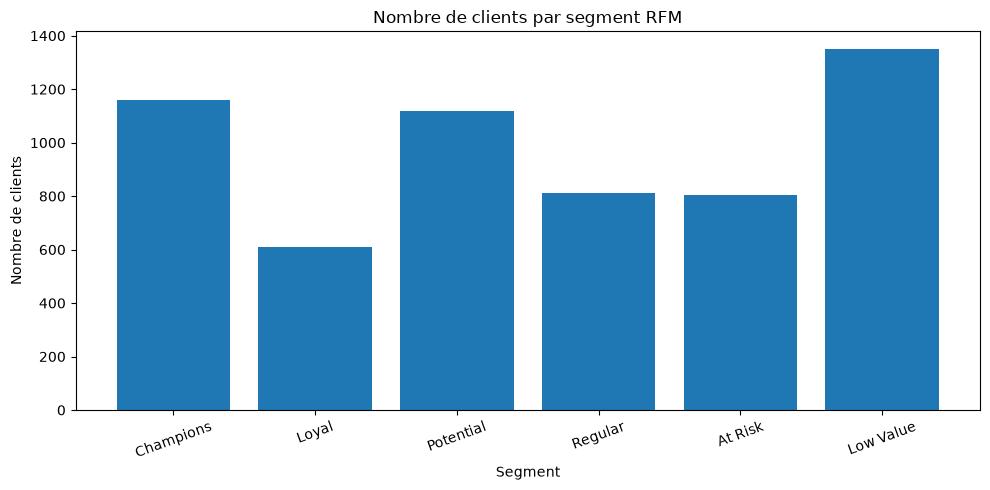

In [19]:
# Graphique : nombre de clients par segment

segment_order = [
    "Champions",
    "Loyal",
    "Potential",
    "Regular",
    "At Risk",
    "Low Value"
]

segment_plot = (
    segment_distribution
    .set_index("segment")
    .reindex(segment_order)
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.bar(
    segment_plot["segment"],
    segment_plot["customers"]
)

plt.title("Nombre de clients par segment RFM")
plt.xlabel("Segment")
plt.ylabel("Nombre de clients")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

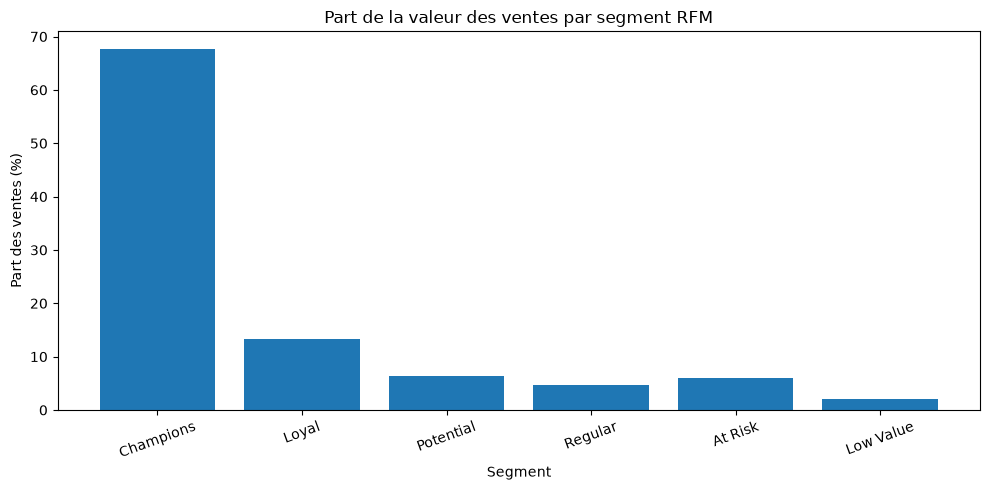

In [20]:
# Graphique : La part des ventes par segment

segment_sales_plot = (
    segment_value
    .set_index("segment")
    .reindex(segment_order)
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.bar(
    segment_sales_plot["segment"],
    segment_sales_plot["sales_share_pct"]
)

plt.title("Part de la valeur des ventes par segment RFM")
plt.xlabel("Segment")
plt.ylabel("Part des ventes (%)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

In [21]:
connection.close()

print("Connexion DuckDB fermée")

Connexion DuckDB fermée
